## Time Resampling

In [2]:
import pandas as pd

In [3]:
pd.date_range(start="01-1-2026" , end="17-4-2026", freq="w")

/tmp/ipykernel_10519/3212764860.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  pd.date_range(start="01-1-2026" , end="17-4-2026", freq="w")


DatetimeIndex(['2026-01-04', '2026-01-11', '2026-01-18', '2026-01-25',
               '2026-02-01', '2026-02-08', '2026-02-15', '2026-02-22',
               '2026-03-01', '2026-03-08', '2026-03-15', '2026-03-22',
               '2026-03-29', '2026-04-05', '2026-04-12'],
              dtype='datetime64[ns]', freq='W-SUN')

In [4]:
df = pd.read_csv("/content/HistoricalData_1749760701437.csv")
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,06/11/2025,$95.39,14835490,$92.11,$95.91,$92.00
1,06/10/2025,$91.43,6911110,$89.90,$91.89,$89.53
2,06/09/2025,$90.67,8097257,$89.08,$91.14,$89.08
3,06/06/2025,$89.64,8772872,$88.40,$89.89,$88.24
4,06/05/2025,$86.99,8479357,$88.18,$88.41,$86.86


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        2515 non-null   object
 1   Close/Last  2515 non-null   object
 2   Volume      2515 non-null   int64 
 3   Open        2515 non-null   object
 4   High        2515 non-null   object
 5   Low         2515 non-null   object
dtypes: int64(1), object(5)
memory usage: 118.0+ KB


In [6]:
pd.to_datetime(df["Date"])

,Date
0,2025-06-11
1,2025-06-10
2,2025-06-09
3,2025-06-06
4,2025-06-05
...,...
2510,2015-06-18
2511,2015-06-17
2512,2015-06-16
2513,2015-06-15


In [8]:
df.iloc[0]

,0
Date,06/11/2025
Close/Last,$95.39
Volume,14835490
Open,$92.11
High,$95.91
Low,$92.00


In [11]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.loc["2015-06-18"]

,2015-06-18
Close/Last,$54.11
Volume,10711720
Open,$53.50
High,$54.28
Low,$53.40


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2025-06-11 to 2015-06-12
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Close/Last  2515 non-null   object
 1   Volume      2515 non-null   int64 
 2   Open        2515 non-null   object
 3   High        2515 non-null   object
 4   Low         2515 non-null   object
dtypes: int64(1), object(4)
memory usage: 182.4+ KB


In [13]:
full_date_range = pd.date_range(start=df.index.min(),end=df.index.max(), freq='B')
print("Full date range with business days")
print(full_date_range)

Full date range with business days
DatetimeIndex(['2015-06-12', '2015-06-15', '2015-06-16', '2015-06-17',
               '2015-06-18', '2015-06-19', '2015-06-22', '2015-06-23',
               '2015-06-24', '2015-06-25',
               ...
               '2025-05-29', '2025-05-30', '2025-06-02', '2025-06-03',
               '2025-06-04', '2025-06-05', '2025-06-06', '2025-06-09',
               '2025-06-10', '2025-06-11'],
              dtype='datetime64[ns]', length=2609, freq='B')


In [14]:
df.index.min()

Timestamp('2015-06-12 00:00:00')

In [15]:
df.index.max()

Timestamp('2025-06-11 00:00:00')

In [16]:
print(df.index.is_monotonic_increasing)

False


In [17]:
df.sort_index()

,Close/Last,Volume,Open,High,Low
Date,,,,,
2015-06-12,$52.63,5234542,$52.41,$52.74,$52.16
2015-06-15,$52.27,5554831,$52.23,$52.46,$52.01
2015-06-16,$52.965,6106122,$52.27,$53.14,$52.20
2015-06-17,$53.24,6734974,$53.09,$53.47,$52.72
2015-06-18,$54.11,10711720,$53.50,$54.28,$53.40
...,...,...,...,...,...
2025-06-05,$86.99,8479357,$88.18,$88.41,$86.86
2025-06-06,$89.64,8772872,$88.40,$89.89,$88.24
2025-06-09,$90.67,8097257,$89.08,$91.14,$89.08


In [19]:
df["Close/Last"].resample(rule= "M")

/tmp/ipykernel_10519/3992847200.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["Close/Last"].resample(rule= "M")


In [22]:
df["Close/Last"].resample(rule= "M").min()

/tmp/ipykernel_10519/4009079331.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["Close/Last"].resample(rule= "M").min()


,Close/Last
Date,
2015-06-30,52.27
2015-07-31,53.39
2015-08-31,50.34
2015-09-30,53.50
2015-10-31,57.48
...,...
2025-02-28,108.16
2025-03-31,95.72
2025-04-30,79.69


/tmp/ipykernel_10519/297528840.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["Close/Last"].resample(rule= "M").min().plot(kind="line" , figsize=(12,5))


<Axes: xlabel='Date'>

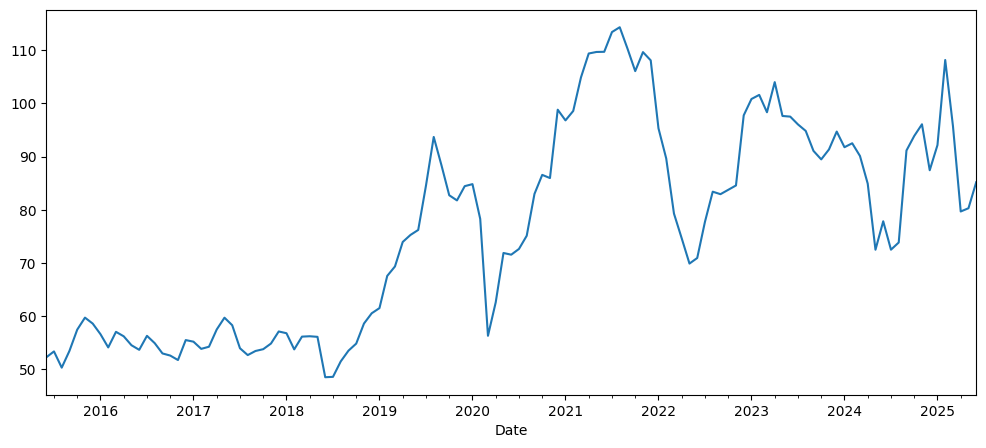

In [25]:
df["Close/Last"].resample(rule= "M").min().plot(kind="line" , figsize=(12,5))

In [23]:
df["Close/Last"].resample(rule= "M").max()

/tmp/ipykernel_10519/721500990.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["Close/Last"].resample(rule= "M").max()


,Close/Last
Date,
2015-06-30,54.62
2015-07-31,58.06
2015-08-31,59.01
2015-09-30,58.37
2015-10-31,63.51
...,...
2025-02-28,115.81
2025-03-31,115.41
2025-04-30,99.41


/tmp/ipykernel_10519/2234450062.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["Close/Last"].resample(rule= "M").max().plot(kind="line" , figsize=(12,5))


<Axes: xlabel='Date'>

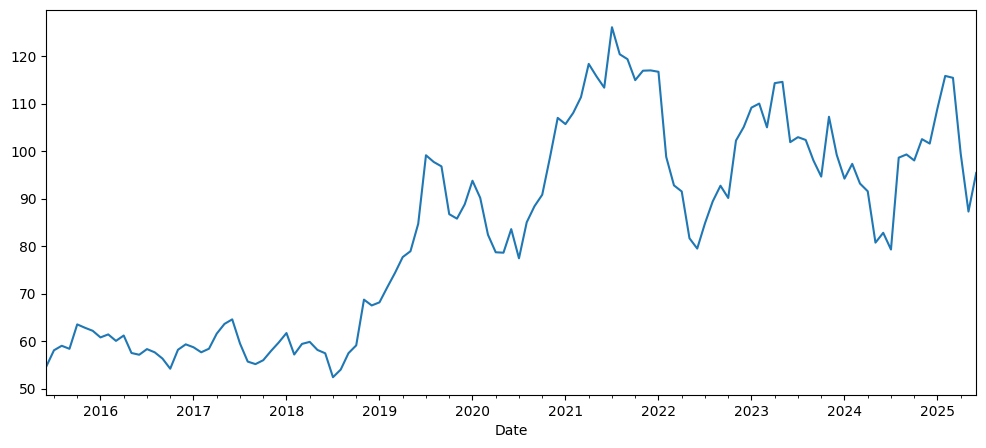

In [24]:
df["Close/Last"].resample(rule= "M").max().plot(kind="line" , figsize=(12,5))

/tmp/ipykernel_10519/1254326888.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df["Close/Last"].resample("Y").mean().plot(kind="bar" , figsize=(12,5))


<Axes: xlabel='Date'>

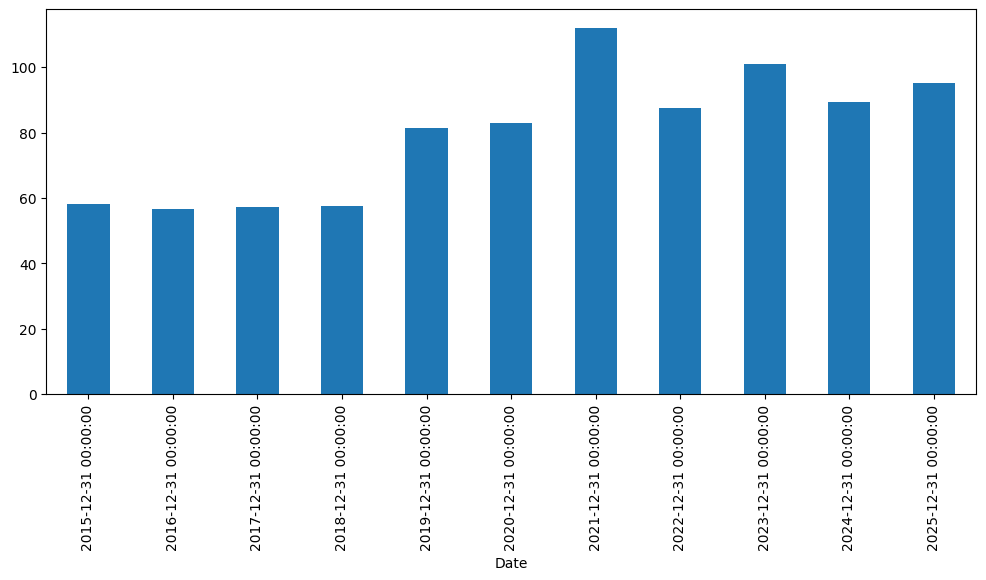

In [21]:
df['Close/Last'] = df['Close/Last'].astype(str).str.replace('$', '', regex=False).astype(float)
df["Close/Last"].resample("Y").mean().plot(kind="bar" , figsize=(12,5))